## 1. Import Required Libraries

In [12]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.impute import SimpleImputer
import pickle

# Ensure Django is configured for ORM access
os.environ.setdefault('DJANGO_ALLOW_ASYNC_UNSAFE', 'true')
project_root = Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
os.environ.setdefault('DJANGO_SETTINGS_MODULE', 'mushroom_dashboard.settings')

import django

django.setup()

from django.utils import timezone

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 2. Load Historical Harvest Data (Farmer Records)

We will train on actual harvested batches stored in the system, not synthetic data. This makes the prediction reflect the farmer's real history.

In [5]:
from core.models import ProductionBatch

# Fetch harvested batches with yield data
batches = list(
    ProductionBatch.objects.filter(
        status='HARVESTED',
        yield_kg__isnull=False,
        harvest_date__isnull=False,
        start_date__isnull=False,
    )
    .select_related('product')
    .order_by('harvest_date', 'start_date', 'id')
)

# Build a training dataset from historical harvests
records = []
farm_history = []
product_history = {}

for batch in batches:
    harvested_yield = float(batch.yield_kg)
    product_id = batch.product_id or -1
    start_date = batch.start_date
    harvest_date = batch.harvest_date
    growth_days = max((harvest_date - start_date).days + 1, 1)

    product_values = product_history.get(product_id, [])

    records.append({
        'product_id': product_id,
        'start_month': start_date.month,
        'growth_days': growth_days,
        'cost': float(batch.cost) if batch.cost is not None else np.nan,
        'same_product_prev_yield_1': float(product_values[-1]) if product_values else np.nan,
        'same_product_prev_avg_3': float(np.mean(product_values[-3:])) if product_values else np.nan,
        'farm_prev_avg_5': float(np.mean(farm_history[-5:])) if farm_history else np.nan,
        'yield_kg': harvested_yield,
    })

    farm_history.append(harvested_yield)
    product_history.setdefault(product_id, []).append(harvested_yield)

data = pd.DataFrame(records)

print(f"Loaded {len(data)} harvested batches for training")
print("\nFirst 5 rows:")
data.head()

Loaded 13 harvested batches for training

First 5 rows:


,product_id,start_month,growth_days,cost,same_product_prev_yield_1,same_product_prev_avg_3,farm_prev_avg_5,yield_kg
0,3,11,4,290.0,NaN,NaN,NaN,3.9
1,5,11,6,200.0,NaN,NaN,3.90,3.8
2,5,11,6,180.0,3.8,3.8,3.85,3.7
3,1,11,11,200.0,NaN,NaN,3.80,4.0
4,1,11,11,150.0,4.0,4.0,3.85,3.0


## 3. Exploratory Data Analysis

In [6]:
# Basic statistics
print("Dataset Statistics:")
data.describe()

Dataset Statistics:


,product_id,start_month,growth_days,cost,same_product_prev_yield_1,same_product_prev_avg_3,farm_prev_avg_5,yield_kg
count,13.000000,13.000000,13.000000,13.000000,9.000000,9.000000,12.000000,13.000000
mean,3.307692,8.769231,10.769231,160.769231,3.866667,3.833333,3.831667,3.861538
std,1.974192,4.023967,6.857524,76.317488,0.393700,0.169763,0.118232,0.333013
min,1.000000,3.000000,1.000000,50.000000,3.000000,3.500000,3.680000,3.000000
25%,1.000000,3.000000,6.000000,100.000000,3.800000,3.750000,3.730000,3.800000
50%,3.000000,11.000000,11.000000,150.000000,3.900000,3.900000,3.825000,3.900000
75%,5.000000,11.000000,14.000000,200.000000,4.000000,3.950000,3.920000,4.000000
max,7.000000,12.000000,21.000000,300.000000,4.500000,4.000000,4.000000,4.500000


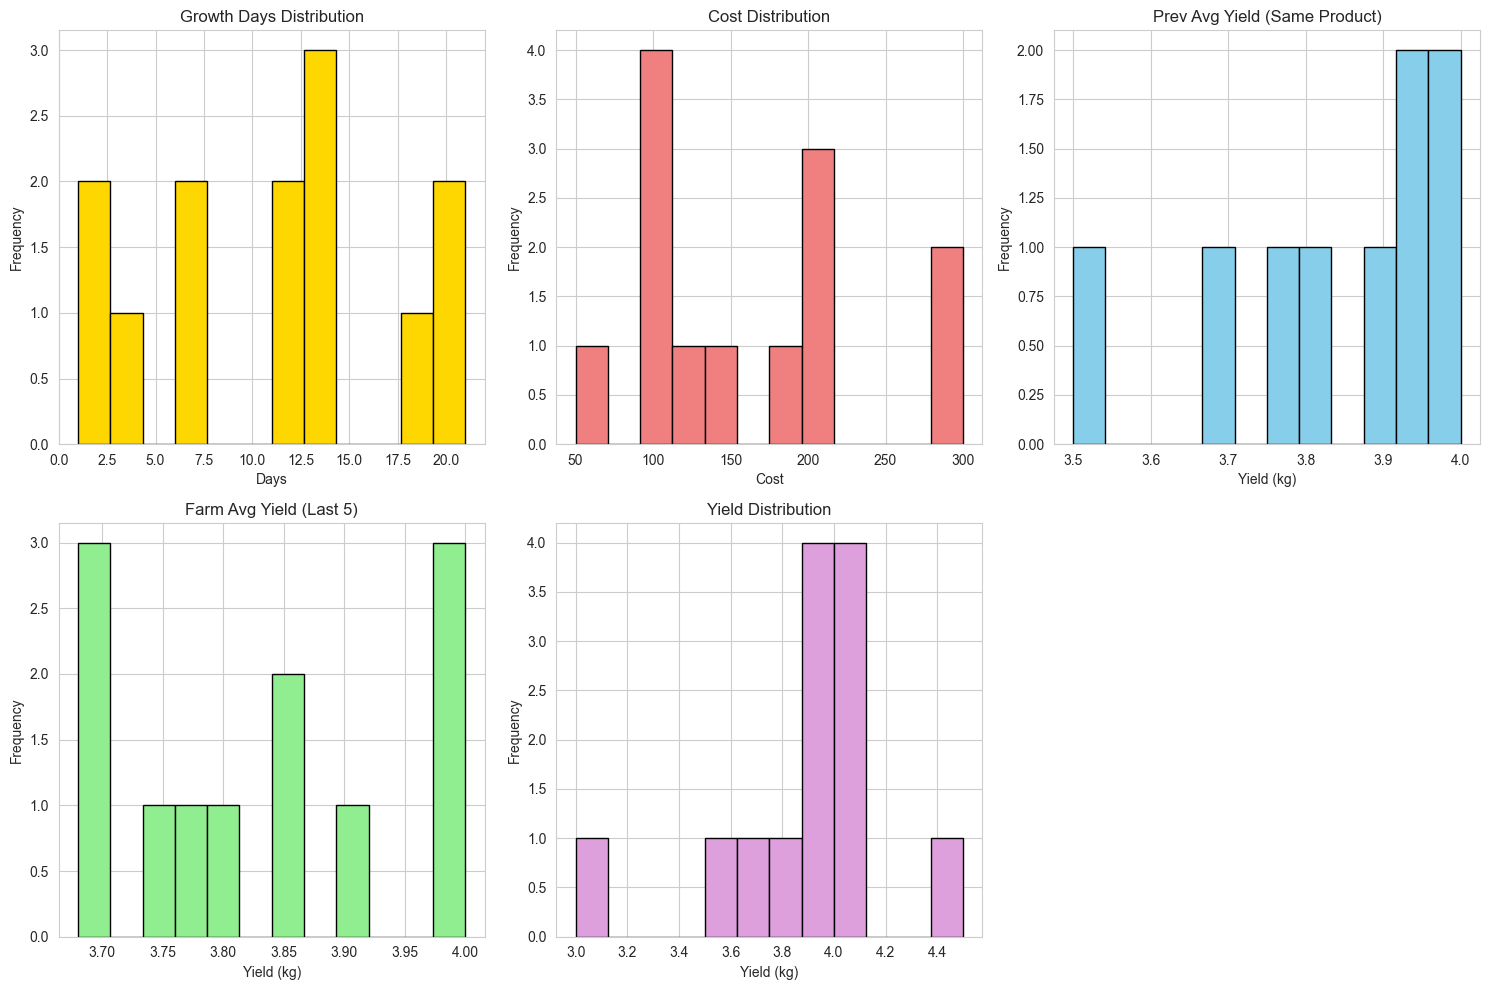

In [7]:
# Visualize distributions for key historical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Growth Days
axes[0, 0].hist(data['growth_days'], bins=12, color='gold', edgecolor='black')
axes[0, 0].set_title('Growth Days Distribution')
axes[0, 0].set_xlabel('Days')
axes[0, 0].set_ylabel('Frequency')

# Cost
axes[0, 1].hist(data['cost'].dropna(), bins=12, color='lightcoral', edgecolor='black')
axes[0, 1].set_title('Cost Distribution')
axes[0, 1].set_xlabel('Cost')
axes[0, 1].set_ylabel('Frequency')

# Previous Yield (Same Product)
axes[0, 2].hist(data['same_product_prev_avg_3'].dropna(), bins=12, color='skyblue', edgecolor='black')
axes[0, 2].set_title('Prev Avg Yield (Same Product)')
axes[0, 2].set_xlabel('Yield (kg)')
axes[0, 2].set_ylabel('Frequency')

# Farm Average Yield (Last 5)
axes[1, 0].hist(data['farm_prev_avg_5'].dropna(), bins=12, color='lightgreen', edgecolor='black')
axes[1, 0].set_title('Farm Avg Yield (Last 5)')
axes[1, 0].set_xlabel('Yield (kg)')
axes[1, 0].set_ylabel('Frequency')

# Yield
axes[1, 1].hist(data['yield_kg'], bins=12, color='plum', edgecolor='black')
axes[1, 1].set_title('Yield Distribution')
axes[1, 1].set_xlabel('Yield (kg)')
axes[1, 1].set_ylabel('Frequency')

# Hide the last subplot
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

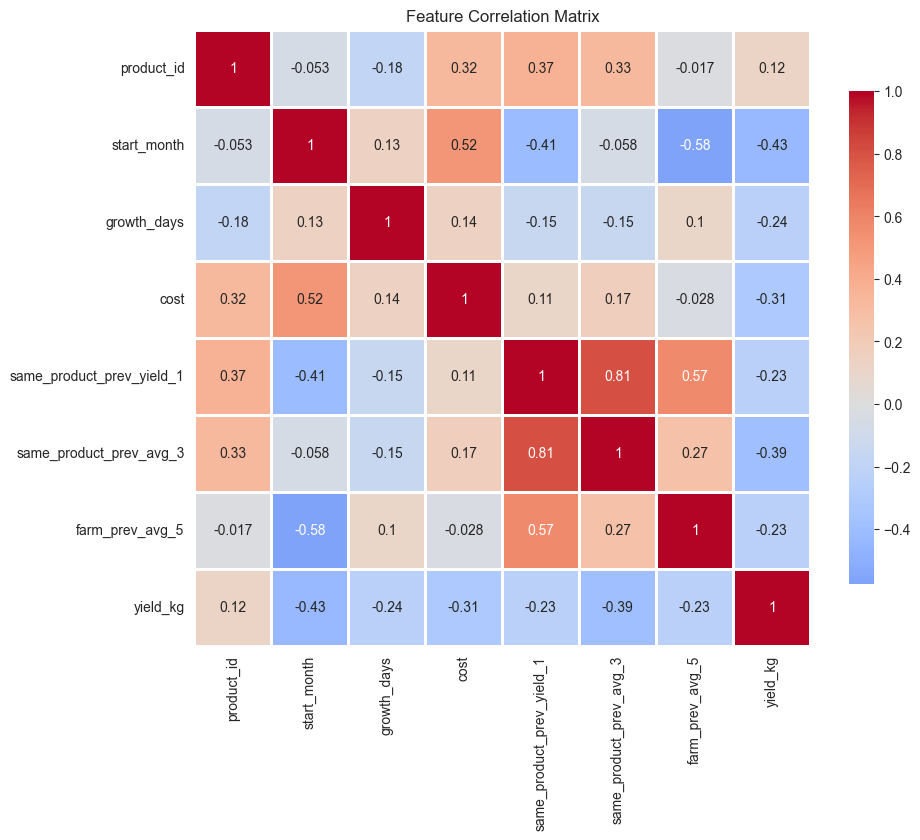


Correlation with Yield:
yield_kg                     1.000000
product_id                   0.120906
same_product_prev_yield_1   -0.231598
farm_prev_avg_5             -0.232625
growth_days                 -0.237756
cost                        -0.313517
same_product_prev_avg_3     -0.393460
start_month                 -0.430051
Name: yield_kg, dtype: float64


In [8]:
# Correlation heatmap for numeric features
plt.figure(figsize=(10, 8))
correlation = data.corr(numeric_only=True)
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix')
plt.show()

print("\nCorrelation with Yield:")
print(correlation['yield_kg'].sort_values(ascending=False))

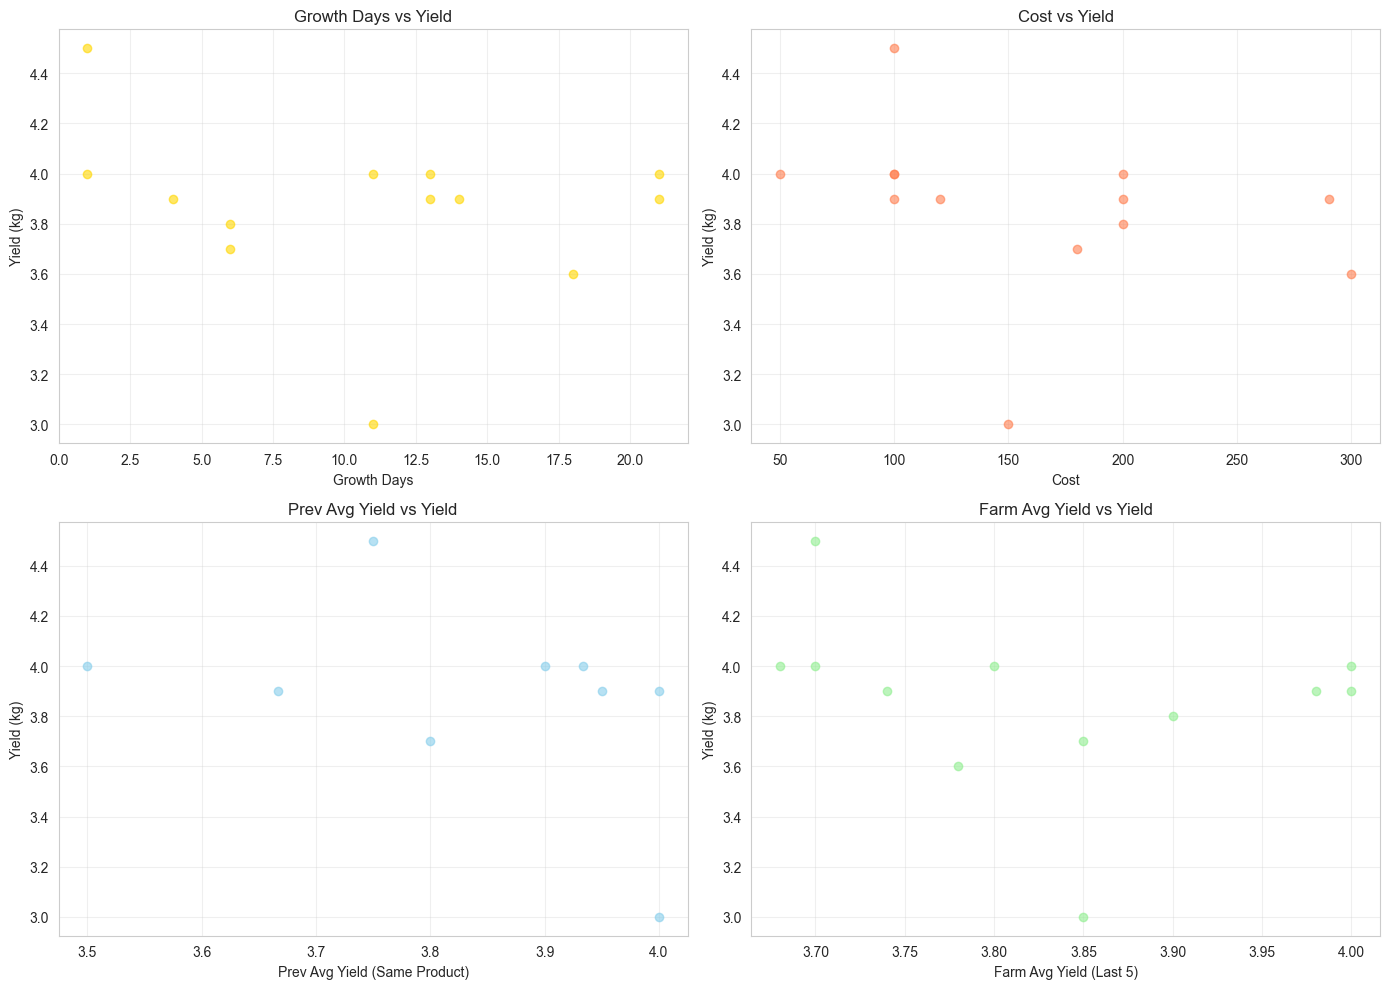

In [9]:
# Scatter plots: Features vs Yield
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Growth Days vs Yield
axes[0, 0].scatter(data['growth_days'], data['yield_kg'], alpha=0.6, color='gold')
axes[0, 0].set_xlabel('Growth Days')
axes[0, 0].set_ylabel('Yield (kg)')
axes[0, 0].set_title('Growth Days vs Yield')
axes[0, 0].grid(True, alpha=0.3)

# Cost vs Yield
axes[0, 1].scatter(data['cost'], data['yield_kg'], alpha=0.6, color='coral')
axes[0, 1].set_xlabel('Cost')
axes[0, 1].set_ylabel('Yield (kg)')
axes[0, 1].set_title('Cost vs Yield')
axes[0, 1].grid(True, alpha=0.3)

# Same Product Prev Avg vs Yield
axes[1, 0].scatter(data['same_product_prev_avg_3'], data['yield_kg'], alpha=0.6, color='skyblue')
axes[1, 0].set_xlabel('Prev Avg Yield (Same Product)')
axes[1, 0].set_ylabel('Yield (kg)')
axes[1, 0].set_title('Prev Avg Yield vs Yield')
axes[1, 0].grid(True, alpha=0.3)

# Farm Prev Avg vs Yield
axes[1, 1].scatter(data['farm_prev_avg_5'], data['yield_kg'], alpha=0.6, color='lightgreen')
axes[1, 1].set_xlabel('Farm Avg Yield (Last 5)')
axes[1, 1].set_ylabel('Yield (kg)')
axes[1, 1].set_title('Farm Avg Yield vs Yield')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Prepare Data for Training

In [10]:
# Separate features and target
feature_columns = [
    'product_id',
    'start_month',
    'growth_days',
    'cost',
    'same_product_prev_yield_1',
    'same_product_prev_avg_3',
    'farm_prev_avg_5'
]
X = data[feature_columns]
y = data['yield_kg']

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")
print(f"\nFeature names: {list(X.columns)}")

Training samples: 10
Testing samples: 3

Feature names: ['product_id', 'start_month', 'growth_days', 'cost', 'same_product_prev_yield_1', 'same_product_prev_avg_3', 'farm_prev_avg_5']


## 5. Train Machine Learning Models

### 5.1 Linear Regression Model

In [13]:
# Train Linear Regression model with median imputation
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

lr_model = LinearRegression()
lr_model.fit(X_train_imputed, y_train)

# Make predictions
y_pred_lr = lr_model.predict(X_test_imputed)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_lr:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lr:.4f} kg")
print(f"  Mean Absolute Error (MAE): {mae_lr:.4f} kg")
print(f"  R² Score: {r2_lr:.4f}")

print("\nModel Coefficients:")
for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"  {feature}: {coef:.4f}")
print(f"  Intercept: {lr_model.intercept_:.4f}")

Linear Regression Model Performance:
  Mean Squared Error (MSE): 0.6832
  Root Mean Squared Error (RMSE): 0.8266 kg
  Mean Absolute Error (MAE): 0.7480 kg
  R² Score: -7.5401

Model Coefficients:
  product_id: -0.0308
  start_month: -0.1790
  growth_days: -0.0261
  cost: 0.0041
  same_product_prev_yield_1: 0.1354
  same_product_prev_avg_3: -1.6224
  farm_prev_avg_5: -4.1079
  Intercept: 26.8028


### 5.2 Random Forest Regression Model

In [14]:
# Train Random Forest model with the same imputation
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_imputed, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_imputed)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Model Performance:")
print(f"  Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.4f} kg")
print(f"  Mean Absolute Error (MAE): {mae_rf:.4f} kg")
print(f"  R² Score: {r2_rf:.4f}")

print("\nFeature Importance:")
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
print(feature_importance)

Random Forest Model Performance:
  Mean Squared Error (MSE): 0.1797
  Root Mean Squared Error (RMSE): 0.4239 kg
  Mean Absolute Error (MAE): 0.2640 kg
  R² Score: -1.2463

Feature Importance:
                     feature  importance
0                 product_id    0.320241
5    same_product_prev_avg_3    0.320103
3                       cost    0.103913
4  same_product_prev_yield_1    0.091913
2                growth_days    0.082570
6            farm_prev_avg_5    0.049825
1                start_month    0.031435


## 6. Visualize Model Performance

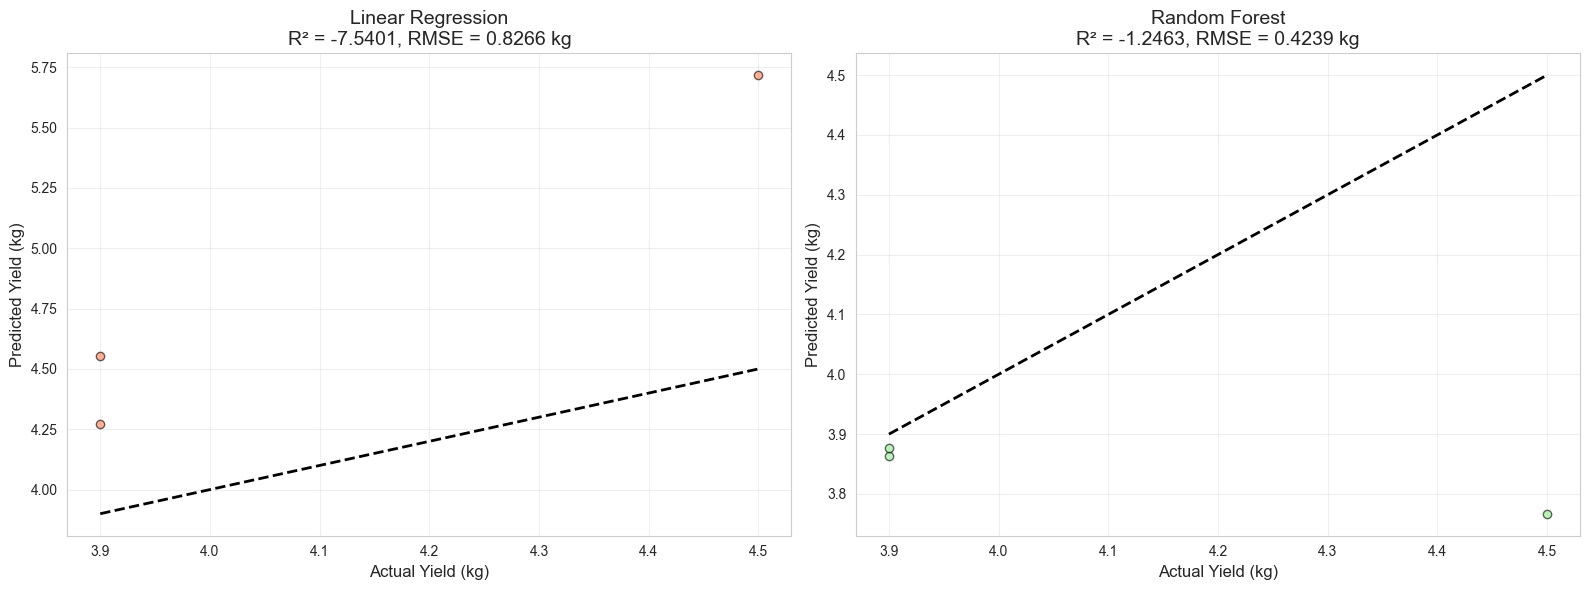

In [15]:
# Compare actual vs predicted values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.6, color='coral', edgecolors='black')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[0].set_xlabel('Actual Yield (kg)', fontsize=12)
axes[0].set_ylabel('Predicted Yield (kg)', fontsize=12)
axes[0].set_title(f'Linear Regression\nR² = {r2_lr:.4f}, RMSE = {rmse_lr:.4f} kg', fontsize=14)
axes[0].grid(True, alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.6, color='lightgreen', edgecolors='black')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
axes[1].set_xlabel('Actual Yield (kg)', fontsize=12)
axes[1].set_ylabel('Predicted Yield (kg)', fontsize=12)
axes[1].set_title(f'Random Forest\nR² = {r2_rf:.4f}, RMSE = {rmse_rf:.4f} kg', fontsize=14)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

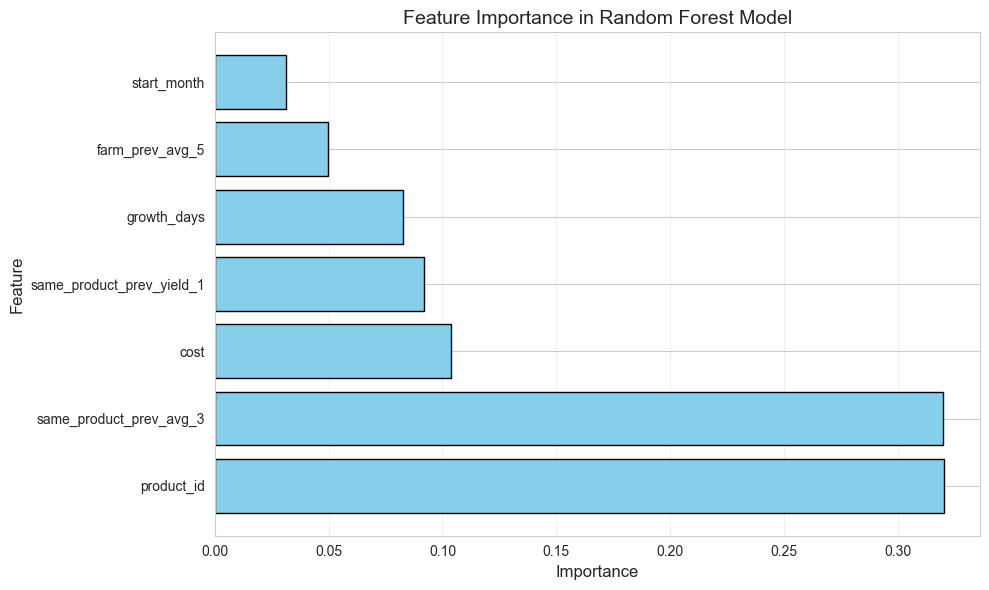

In [16]:
# Feature importance visualization for Random Forest
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'], color='skyblue', edgecolor='black')
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance in Random Forest Model', fontsize=14)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Make Predictions with New Data

In [17]:
# Example: Predict yield for a new batch using farmer history
most_common_product = int(data['product_id'].mode()[0]) if not data.empty else -1

example_conditions = pd.DataFrame({
    'product_id': [most_common_product],
    'start_month': [timezone.now().month],
    'growth_days': [33],
    'cost': [data['cost'].median() if not data['cost'].dropna().empty else np.nan],
    'same_product_prev_yield_1': [data.loc[data['product_id'] == most_common_product, 'yield_kg'].iloc[-1]
                                  if (not data.empty and (data['product_id'] == most_common_product).any())
                                  else np.nan],
    'same_product_prev_avg_3': [data.loc[data['product_id'] == most_common_product, 'yield_kg'].tail(3).mean()
                                if (not data.empty and (data['product_id'] == most_common_product).any())
                                else np.nan],
    'farm_prev_avg_5': [data['yield_kg'].tail(5).mean() if not data.empty else np.nan]
})

prediction_lr = lr_model.predict(example_conditions)
prediction_rf = rf_model.predict(example_conditions)

print("Predicted Yield for Example Batch:")
print(f"  Product ID: {example_conditions['product_id'][0]}")
print(f"  Start Month: {example_conditions['start_month'][0]}")
print(f"  Growth Days: {example_conditions['growth_days'][0]}")
print(f"  Cost: {example_conditions['cost'][0]}")
print(f"\n  Linear Regression Prediction: {prediction_lr[0]:.2f} kg")
print(f"  Random Forest Prediction: {prediction_rf[0]:.2f} kg")

Predicted Yield for Example Batch:
  Product ID: 1
  Start Month: 5
  Growth Days: 33
  Cost: 150.0

  Linear Regression Prediction: 3.92 kg
  Random Forest Prediction: 3.88 kg


c:\Users\Dan Kirvy\Desktop\Capstone Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\Dan Kirvy\Desktop\Capstone Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [18]:
# Example: Predict yield for a different product or higher cost scenario
alt_product_id = int(data['product_id'].unique()[-1]) if not data.empty else -1

suboptimal_conditions = pd.DataFrame({
    'product_id': [alt_product_id],
    'start_month': [max(1, timezone.now().month - 1)],
    'growth_days': [28],
    'cost': [data['cost'].quantile(0.75) if not data['cost'].dropna().empty else np.nan],
    'same_product_prev_yield_1': [data.loc[data['product_id'] == alt_product_id, 'yield_kg'].iloc[-1]
                                  if (not data.empty and (data['product_id'] == alt_product_id).any())
                                  else np.nan],
    'same_product_prev_avg_3': [data.loc[data['product_id'] == alt_product_id, 'yield_kg'].tail(3).mean()
                                if (not data.empty and (data['product_id'] == alt_product_id).any())
                                else np.nan],
    'farm_prev_avg_5': [data['yield_kg'].tail(5).mean() if not data.empty else np.nan]
})

prediction_lr = lr_model.predict(suboptimal_conditions)
prediction_rf = rf_model.predict(suboptimal_conditions)

print("Predicted Yield for Alternate Batch:")
print(f"  Product ID: {suboptimal_conditions['product_id'][0]}")
print(f"  Start Month: {suboptimal_conditions['start_month'][0]}")
print(f"  Growth Days: {suboptimal_conditions['growth_days'][0]}")
print(f"  Cost: {suboptimal_conditions['cost'][0]}")
print(f"\n  Linear Regression Prediction: {prediction_lr[0]:.2f} kg")
print(f"  Random Forest Prediction: {prediction_rf[0]:.2f} kg")

Predicted Yield for Alternate Batch:
  Product ID: 7
  Start Month: 4
  Growth Days: 28
  Cost: 200.0

  Linear Regression Prediction: 4.27 kg
  Random Forest Prediction: 3.76 kg


c:\Users\Dan Kirvy\Desktop\Capstone Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
c:\Users\Dan Kirvy\Desktop\Capstone Project\.venv\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


## 8. Save the Model

In [19]:
# Save the Random Forest model (better performance)
model_filename = 'mushroom_yield_model.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)

print(f"Model saved as '{model_filename}'")
print("\nYou can load it later using:")
print("  with open('mushroom_yield_model.pkl', 'rb') as file:")
print("      model = pickle.load(file)")

Model saved as 'mushroom_yield_model.pkl'

You can load it later using:
  with open('mushroom_yield_model.pkl', 'rb') as file:
      model = pickle.load(file)


## 9. Integration Guide for Django App

To integrate this model into your Django mushroom dashboard using farmer harvest history:

1. **Train the model from harvested batches** using the management command:
   ```bash
   py manage.py train_yield_model
   ```

2. **Use the prediction helper** in `core/yield_model.py`:
   ```python
   from core.yield_model import calculate_predicted_yield

   predicted = calculate_predicted_yield(
       product_id=product_id,
       start_date=start_date,
       cost=cost
   )
   ```

3. **Use in production batches**: Store `predicted_yield_kg` when a new batch is created.

4. **Display predictions**: Show predicted vs actual yield in the production and analytics pages.

This approach keeps the prediction grounded in the farmer’s own harvest history rather than synthetic data.